In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from src.utils.seeds import set_seed
from src.data.simulation import (
    make_stable_var_matrix,
    simulate_var_with_innovations,
    generate_gaussian_innovations,
    generate_student_t_innovations,
    generate_mixture_innovations,
    generate_heteroskedastic_innovations,
)
from src.var.fit import fit_var_ols
from src.innovations.diagnostics import summarize_innovation_diagnostics

set_seed(123)

In [10]:
k = 3
n_obs = 400
burn_in = 100
lags = 1

A = make_stable_var_matrix(k=k, scale=0.45, seed=123)

Sigma = np.array([
    [1.0, 0.3, 0.1],
    [0.3, 1.0, 0.2],
    [0.1, 0.2, 1.0],
])

Sigma_high = 9.0 * Sigma

In [11]:
innovation_sets = {
    "Gaussian": generate_gaussian_innovations(
        n_obs=n_obs + burn_in,
        Sigma=Sigma,
        seed=1,
    ),
    "Student-t": generate_student_t_innovations(
        n_obs=n_obs + burn_in,
        Sigma=Sigma,
        df=2.5,
        seed=2,
    ),
    "Mixture": generate_mixture_innovations(
        n_obs=n_obs + burn_in,
        Sigma_low=Sigma,
        Sigma_high=Sigma_high,
        high_prob=0.15,
        seed=3,
    ),
    "Heteroskedastic": generate_heteroskedastic_innovations(
        n_obs=n_obs + burn_in,
        k=k,
        base_scale=0.4,
        high_scale=2.5,
        period=40,
        seed=4,
    ),
}

In [12]:
datasets = {}

for name, innovations in innovation_sets.items():
    y = simulate_var_with_innovations(
        A=A,
        innovations=innovations,
        burn_in=burn_in,
    )
    datasets[name] = y

    print(name, y.shape)

Gaussian (400, 3)
Student-t (400, 3)
Mixture (400, 3)
Heteroskedastic (400, 3)


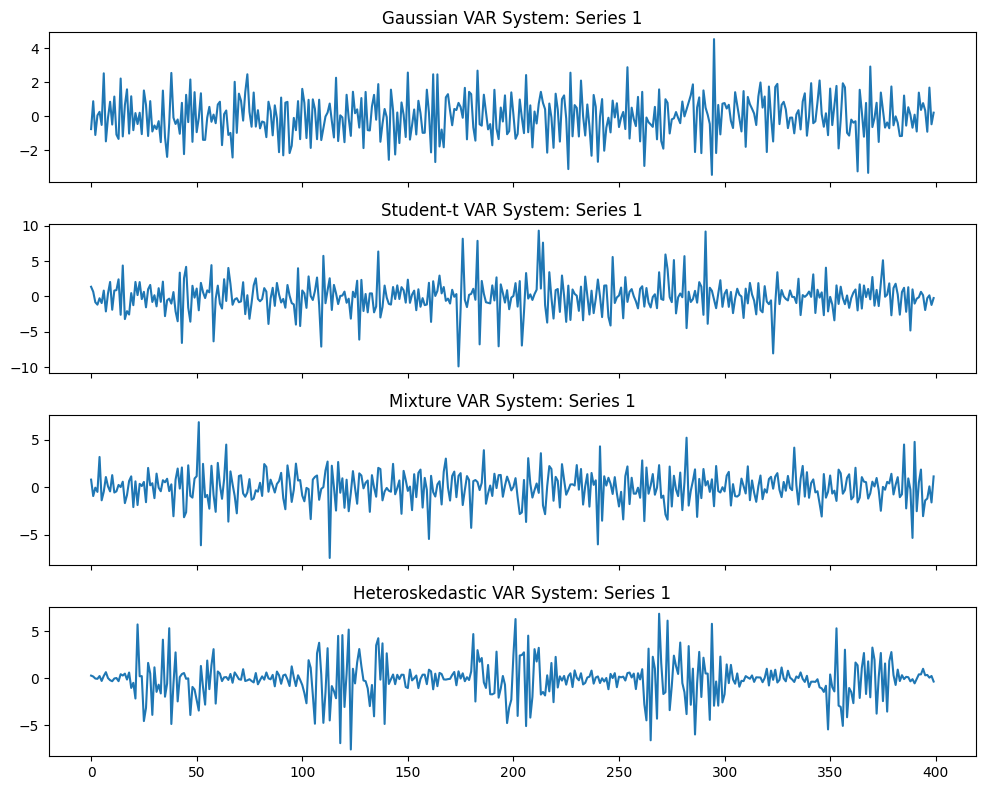

In [13]:
fig, axes = plt.subplots(len(datasets), 1, figsize=(10, 8), sharex=True)

for ax, (name, y) in zip(axes, datasets.items()):
    ax.plot(y[:, 0])
    ax.set_title(f"{name} VAR System: Series 1")

plt.tight_layout()
plt.show()

In [14]:
diagnostic_rows = []
residual_store = {}

for name, y in datasets.items():
    fit = fit_var_ols(y, lags=lags)
    residuals = fit["residuals"]
    residual_store[name] = residuals

    diag = summarize_innovation_diagnostics(residuals)

    for j in range(k):
        diagnostic_rows.append({
            "system": name,
            "series": j + 1,
            "mean": diag["mean"][j],
            "std": diag["std"][j],
            "skewness": diag["skewness"][j],
            "kurtosis": diag["kurtosis"][j],
            "excess_kurtosis": diag["excess_kurtosis"][j],
            "jb_stat": diag["jarque_bera_stat"][j],
            "jb_pvalue": diag["jarque_bera_pvalue"][j],
        })

diagnostics_df = pd.DataFrame(diagnostic_rows)
diagnostics_df

,system,series,mean,std,skewness,kurtosis,excess_kurtosis,jb_stat,jb_pvalue
0,Gaussian,1,3.297279e-17,0.969261,0.022393,3.010010,0.010010,0.033531,9.833745e-01
1,Gaussian,2,-4.730274e-17,1.036567,0.113002,3.182861,0.182861,1.298584,5.224154e-01
2,Gaussian,3,-1.669508e-17,1.051287,0.075921,3.134927,0.134927,0.612858,7.360707e-01
3,Student-t,1,-1.828112e-16,1.851034,0.586972,11.192988,8.192988,1106.965166,4.222488e-241
4,Student-t,2,4.173771e-18,1.951678,1.931166,16.179160,13.179160,3055.588248,0.000000e+00
5,Student-t,3,-1.516470e-16,2.284807,-1.328520,20.340905,17.340905,4983.129063,0.000000e+00
6,Mixture,1,-3.144241e-17,1.368760,0.128688,7.207791,4.207791,286.072805,7.587167e-63
7,Mixture,2,6.900634e-17,1.467511,-0.177197,6.606729,3.606729,211.198406,1.376730e-46
8,Mixture,3,-9.293596e-17,1.554575,-0.213563,8.428635,5.428635,478.120518,1.504695e-104
9,Heteroskedastic,1,-1.009357e-16,1.793275,-0.230096,5.221306,2.221306,82.399151,1.280123e-18


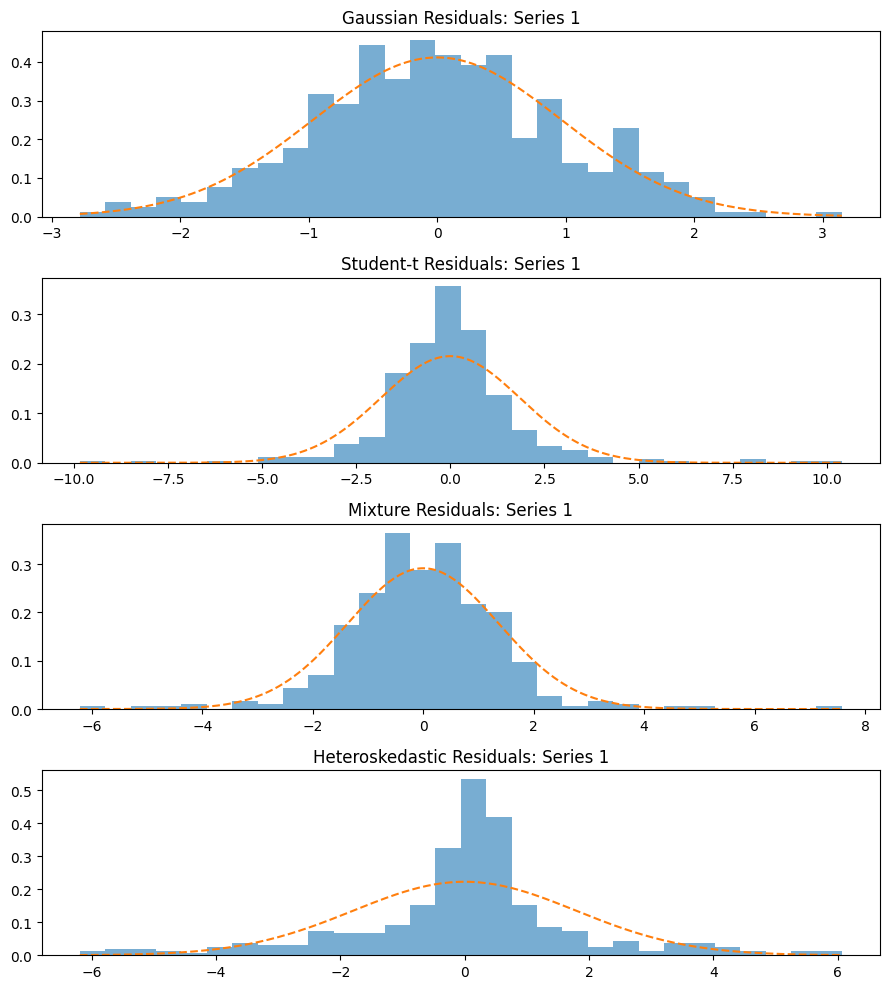

In [15]:
def plot_residual_histograms(residual_store, variable=0):
    n = len(residual_store)
    fig, axes = plt.subplots(n, 1, figsize=(9, 2.5 * n))

    for ax, (name, residuals) in zip(axes, residual_store.items()):
        x = residuals[:, variable]
        ax.hist(x, bins=30, density=True, alpha=0.6)

        grid = np.linspace(x.min(), x.max(), 300)
        normal_pdf = stats.norm.pdf(grid, loc=x.mean(), scale=x.std(ddof=1))
        ax.plot(grid, normal_pdf, linestyle="--")

        ax.set_title(f"{name} Residuals: Series {variable + 1}")

    plt.tight_layout()
    plt.show()


plot_residual_histograms(residual_store, variable=0)

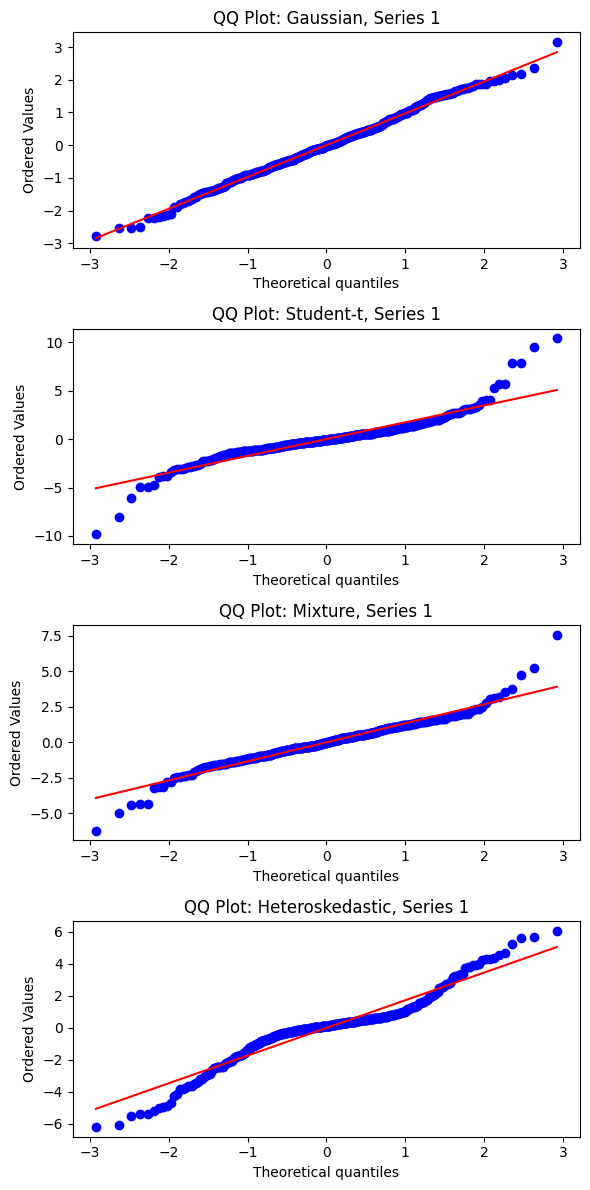

In [18]:
def plot_qq(residual_store, variable=0):
    n = len(residual_store)
    fig, axes = plt.subplots(n, 1, figsize=(6, 3 * n))

    for ax, (name, residuals) in zip(axes, residual_store.items()):
        stats.probplot(residuals[:, variable], dist="norm", plot=ax)
        ax.set_title(f"QQ Plot: {name}, Series {variable + 1}")

    plt.tight_layout()
    plt.show()


plot_qq(residual_store, variable=0)

In [19]:
diagnostics_df.groupby("system")[[
    "skewness",
    "kurtosis",
    "excess_kurtosis",
    "jb_pvalue",
]].mean()

,skewness,kurtosis,excess_kurtosis,jb_pvalue
system,,,,
Gaussian,0.070439,3.109266,0.109266,7.472869e-01
Heteroskedastic,-0.265982,6.141118,3.141118,4.267078e-19
Mixture,-0.087357,7.414385,4.414385,4.589100e-47
Student-t,0.396539,15.904351,12.904351,1.407496e-241
